Saving ASD meta abundance.csv to ASD meta abundance (1).csv
 Dataset Loaded Successfully
Shape: (5619, 61)
Columns: Index(['Taxonomy', 'A3', 'A5', 'A6', 'A9', 'A31', 'A51', 'A52', 'A53', 'A54',
       'A59', 'A67', 'A68', 'A69', 'A71', 'A73', 'A76', 'A78', 'A87', 'A89',
       'A93', 'A101', 'A109', 'A113', 'A114', 'A115', 'A142', 'A144', 'A149',
       'A164', 'A165', 'B1', 'B2', 'B3', 'B5', 'B6', 'B7', 'B8', 'B13', 'B14',
       'B28', 'B29', 'B36', 'B37', 'B94', 'B99', 'B103', 'B106', 'B111',
       'B114', 'B115', 'B120', 'B127', 'B132', 'B141', 'B142', 'B143', 'B152',
       'B156', 'B158', 'B164'],
      dtype='object')
                                            Taxonomy    A3    A5    A6    A9  \
0  g__Faecalibacterium;s__Faecalibacterium prausn...  4988  5060  2905  5745   
1              g__Hungatella;s__Hungatella hathewayi  5803  5612  4109  1432   
2       g__Clostridium;s__uncultured Clostridium sp.  3793  2795  1355  5558   
3           g__Butyricimonas;s__Butyricimonas 

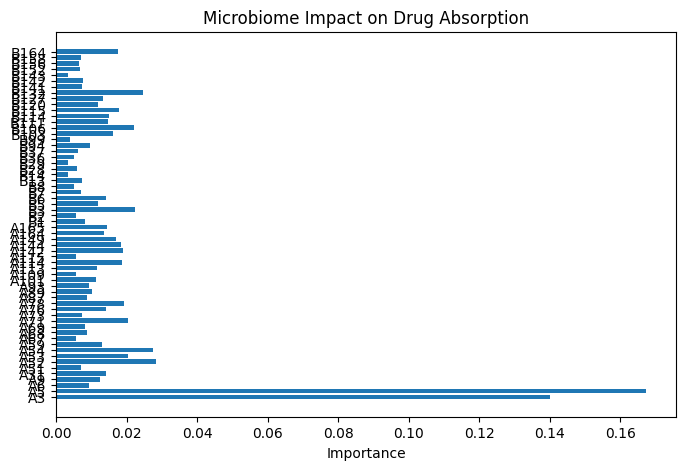

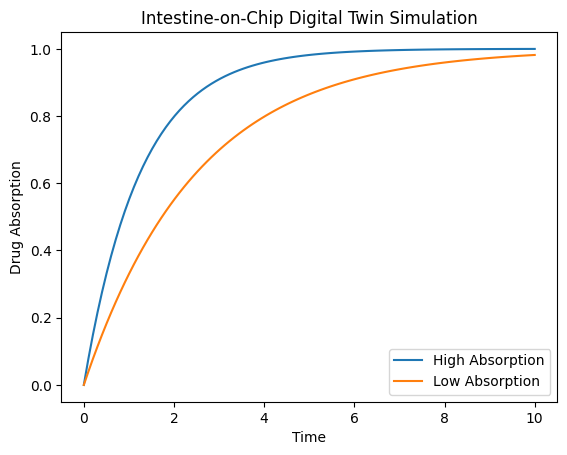

In [13]:
# ==========================================
# STEP 1: Upload Dataset (INTERACTIVE)
# ==========================================
from google.colab import files
uploaded = files.upload()

# Get uploaded file name automatically
file_name = list(uploaded.keys())[0]

# ==========================================
# STEP 2: Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# STEP 3: Load Dataset
# ==========================================
data = pd.read_csv(file_name)

print(" Dataset Loaded Successfully")
print("Shape:", data.shape)
print("Columns:", data.columns)
print(data.head())

# ==========================================
# STEP 4: Data Cleaning
# ==========================================
# Keep only numeric columns
data = data.select_dtypes(include=['float64', 'int64'])

# Fill missing values
data = data.fillna(data.mean())

print("\nAfter Cleaning Shape:", data.shape)

# ==========================================
# STEP 5: Create Drug Absorption (MODEL)
# ==========================================
# Automatically select first 3 columns (microbiome features)
cols = data.columns[:3]

data['drug_absorption'] = (
    0.5 * data[cols[0]] +
    0.3 * data[cols[1]] -
    0.2 * data[cols[2]]
)

# Add biological noise
data['drug_absorption'] += np.random.normal(0, 0.05, len(data))

# Convert to classification
data['absorption_class'] = (
    data['drug_absorption'] > data['drug_absorption'].median()
).astype(int)

print("\nDrug Absorption Created ")

# ==========================================
# STEP 6: Train-Test Split
# ==========================================
from sklearn.model_selection import train_test_split

X = data.drop(columns=['drug_absorption', 'absorption_class'])
y = data['absorption_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nData Split Done ")

# ==========================================
# STEP 7: Train Model
# ==========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=150)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nModel Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ==========================================
# STEP 8: Feature Importance
# ==========================================
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.title("Microbiome Impact on Drug Absorption")
plt.xlabel("Importance")
plt.show()

# ==========================================
# STEP 9: Digital Twin Simulation
# ==========================================
time = np.linspace(0, 10, 100)

def absorption_curve(rate):
    return 1 - np.exp(-rate * time)

plt.figure()
plt.plot(time, absorption_curve(0.8), label="High Absorption")
plt.plot(time, absorption_curve(0.4), label="Low Absorption")

plt.xlabel("Time")
plt.ylabel("Drug Absorption")
plt.title("Intestine-on-Chip Digital Twin Simulation")
plt.legend()
plt.show()